In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 -4*x+5

In [3]:
f(3.0)

20.0

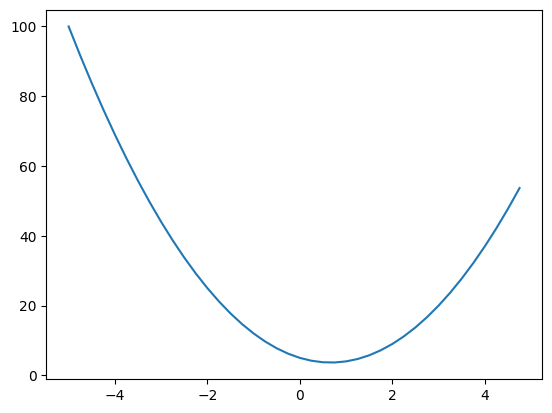

In [4]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)


In [5]:
h=0.001
x=3.0
(f(x+h)-f(x))/h

14.00300000000243

In [6]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [7]:
h=0.0001
d1=a*b+c
a+=h
d2=a*b+c
print(d1)
print(d2)
# dh/dc
print('slope',(d2-d1)/h)

4.0
3.999699999999999
slope -3.000000000010772


In [8]:
class Value:
    def __init__(self,data,_children=(),_op="",label=''):
        self.data=data
        self.grad=0.0
        self._backward=lambda:None
        self._prev=set(_children)
        self._op=_op
        self.label=label
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),_op='+')
        def _backward():
            self.grad+=1.0*out.grad # 现有out的梯度这个才能算
            other.grad+=1.0*out.grad
        # 一个节点的backward不是算自己的梯度而是自己的母节点的梯度
        out._backward=_backward 
        return out
    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),_op='*')
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out
    def __sub__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data-other.data,_children=(self,other,),_op='-')
        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=-1.0*out.grad
        out._backward=_backward
        return out
    def __neg__(self):
        return self*-1
    def __truediv__(self, other):
        return self*other**-1
    
    def __pow__(self,other):
        assert isinstance(other,(int,float))
        out=Value(self.data**other,(self,),f'**{other}')
        def _backward():
            self.grad+=other*self.data**(other-1)*out.grad
        out._backward=_backward
        return out
    
    def __radd__(self,other):
        return self+other
    
    def __rmul__(self,other):
        return self*other
    
    def __rsub__(self,other):
        other =other if isinstance(other,Value) else Value(other)
        return other-self
    
    def __rtruediv__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        return other/self

    def tanh(self):
        n=self.data
        t=(math.exp(2*n)-1)/(math.exp(2*n)+1)
        out=Value(t,(self,),_op='tanh')
        def _backward():
            self.grad+=(1-t**2)*out.grad
        out._backward=_backward
        return out
    
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,),'exp')
        def _backward():
            self.grad=out.data*out.grad
        out._backward=_backward
        return out

    def backward(self):
        topo=[]
        visited=set()
        # 保证被运算出的节点永远在算出他的因子的后面
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        # 先让后面的节点反向传播 
        self.grad=1.0
        for node in reversed(topo):
            node._backward()        


In [9]:
a=Value(2.0,label='a')
b=Value(4.0,label='b')
-a

Value(data=-2.0)

In [10]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

from graphviz import Digraph

def trace(root):
    nodes,edges=set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot=Digraph(format='svg',graph_attr={'rankdir':'LR'})
    nodes,edges=trace(root)
    for n in nodes:
        uid=str(id(n))

        dot.node(name=uid,label="{ %s|data %.4f|grad%.4f}"%(n.label,n.data,n.grad),shape='record')
        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)
    
    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    return dot 

0.0


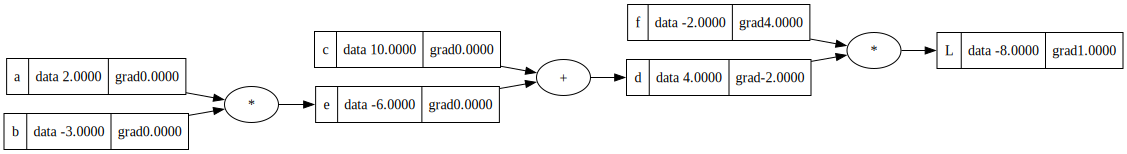

In [11]:
def lol():
    h=0.0001
    # calculate the derivative of L
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e=a*b; e.label='e'
    d = e + c
    d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f
    L.label = 'L'
    L1=L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e=a*b; e.label='e'
    d = e + c
    d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f
    L.label = 'L'
    L2=L.data

    # grad
    f.grad=4
    d.grad=-2
    L.grad=1


    
    
    print((L2-L1)/h)
    return L
L=lol()
draw_dot(L)

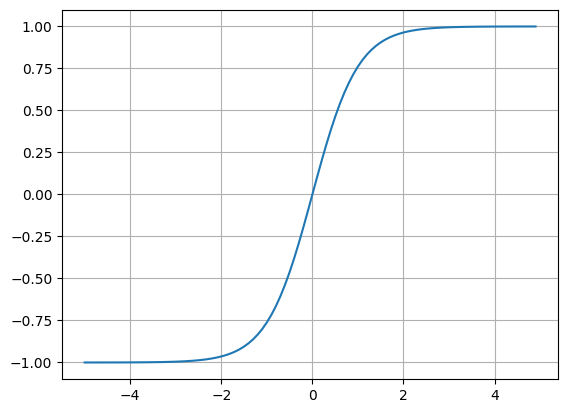

In [12]:
plt.plot(np.arange(-5,5,0.1),np.tanh(np.arange(-5,5,0.1)));plt.grid();


In [13]:
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.8813,label='b')
x1w1=x1*w1; x1w1.label='x1w1'
x2w2=x2*w2; x2w2.label='x2w2'
x1w1x2w2=x1w1+x2w2;x1w1x2w2.label='x1w1+x2w2'
n=x1w1x2w2+b;n.label='n'

#o=n.tanh()
e=(n*2).exp()
o=(e-1)/(e+1)
o.label='o'


In [14]:
o.grad=1.0
# 手动算梯度
# n.grad=1-o.data**2
# x1w1.grad=n.grad
# x2w2.grad=n.grad
# w1.grad=x1.data*x1w1.grad
# w2.grad=x2.data*x2w2.grad
# x1.grad=w1.data*x1w1.grad
# x2.grad=w2.data*x2w2.grad


In [15]:
# 写了反向传播但是manually调用

# o._backward()
# n._backward()
# x1w1x2w2._backward()
# b._backward()
# x1w1._backward()
# x2w2._backward()
# x1._backward()
# x2._backward()
# w1._backward()
# w2._backward()

上面两种方法还是手动调用的,于是我们想封装起来自动跑,但是调用_backward有个问题是,算某节点梯度的时候他的后面节点的梯度必须已知,这是由多层函数的导数相乘的法则决定的,所以我们必须先算后面的点的梯度,后算前面的,而我们需要对什么是"后"(or右)什么是"前"(or左)进行排序,也就是topo order 

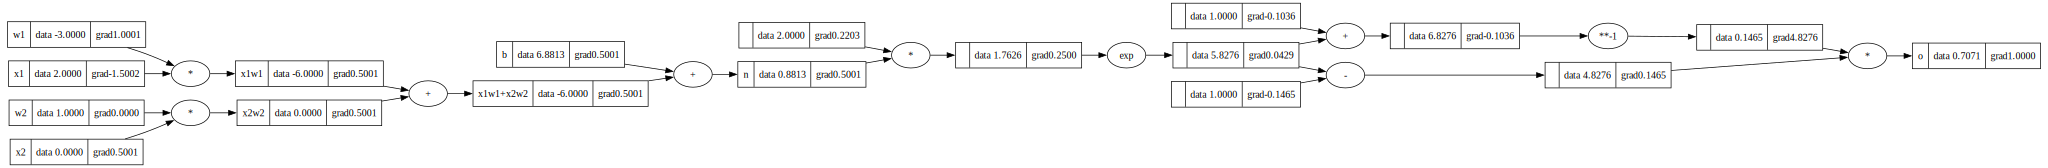

In [16]:
#封装形式的反向传播
o.backward()
draw_dot(o)

一个新的问题是:

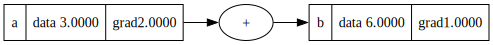

In [17]:
a=Value(3.0,label='a')
b=a+a; b.label='b'
b.backward()
draw_dot(b)

清楚注意到a.grad=1,实际上应该是2,这是因为调用的
def __add__(self,other): 其中self和other其实是同一个object,调用_backward的时候self.grad=1 other.grad=1是覆盖了上一个代码,结果a.grad一直是1,实际上应该+,故改为self.grad+=... other.grad+=...

In [18]:
import torch

In [19]:
x1=torch.Tensor([2.0]).double(); x1.requires_grad=True
x2=torch.Tensor([0.0]).double(); x2.requires_grad=True
w1=torch.Tensor([-3.0]).double(); w1.requires_grad=True
w2=torch.Tensor([1.0]).double();w2.requires_grad=True
b=torch.Tensor([6.88137]).double();b.requires_grad=True
n=w1*x1+w2*x2+b
o=torch.tanh(n)
print(o.data.item())
o.backward()
print('===')
print('x1 ',x1.grad.item())
print('x2 ',x2.grad.item())
print('w1 ',w1.grad.item())
print('w2 ',w2.grad.item())


0.7071050214706146
===
x1  -1.500007465833125
x2  0.5000024886110417
w1  1.0000049772220834
w2  0.0


In [20]:
torch.Tensor([2.0]).double().dtype

torch.float64

In [21]:
a=3.4
type(a) # 64位

float

In [22]:
torch.Tensor([[1,2,3],[4,5,6]])

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [23]:
# item
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [24]:
o.item()

0.7071050214706146

In [25]:
import random


class Neuron:

    def __init__(self,nin) -> None:
        self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b=Value(random.uniform(-1,1))
    def __call__(self,x):
        # zip 把两个迭代器缝合成一个迭代器,一一对应绑定,这俩迭代器元素个数相同
        act=sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out=act.tanh()
        return out
    def parameters(self):
        return self.w+[self.b]

x=[2.0,3.0]
n=Neuron(2)
n(x)

Value(data=-0.9947753190425664)

list算iterator吗       

● 不算。list 是 iterable（可迭代对象），不是 iterator（迭代器）。                                                                                                                   
  # iterable 有 __iter__，但没有 __next__
  print(hasattr(lst, '__iter__'))  # True
  print(hasattr(lst, '__next__')) # False

  # iterator 两者都有
  it = iter(lst)
  print(hasattr(it, '__iter__'))  # True
  print(hasattr(it, '__next__')) # True

  简单说：
  - iterable：能被 for 遍历的东西（list、dict、str 等）
  - iterator：能用 next() 逐个取值的东西，取完就抛 StopIteration

  iter() 把 iterable 变成 iterator，list 本身只能遍历，不能 next()。

In [26]:
class Layer():
    def __init__(self,nin,nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]
    def __call__(self,x):
        outs= [n(x)  for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    def parameters(self):
        # return [p for neuron in self.neurons for p in neuron.parameters()]
        params=[]
        for neutron in self.neurons:
            params.extend(neutron.parameters())
        return params # [[w1,w2,b],[]...    ]
        
        

 Neuron(x)怎么区别是在初始化还是在调用 ?

 Python 不靠函数名区分，靠对象是否已存在：
  -不存在-> 类名(...) → 永远走 __init__
  -存在->实例(...) → 永远走 __call__

In [27]:
x=[2.0,3.0]
n=Layer(2,3)
n(x)

[Value(data=0.8908018843283185),
 Value(data=0.9087287317491095),
 Value(data=-0.9823894363083371)]

拼接
[1, 2] + [3, 4]  # [1, 2, 3, 4]   

In [28]:
class MLP:
    def __init__(self,nin,nouts):
        sz=[nin]+nouts 
        self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers  for p in layer.parameters()]        

In [29]:
x=[2.0,3.0,1.0]
# 3 4 4 1
mlp=MLP(3,[4,4,1])
mlp(x)



Value(data=0.9198212847734574)

In [30]:
mlp.parameters()

[Value(data=0.13914883250534582),
 Value(data=-0.38142023932036184),
 Value(data=-0.9104742183682648),
 Value(data=-0.49410778031360425),
 Value(data=-0.6936609200648183),
 Value(data=-0.2311413314395494),
 Value(data=-0.4445130653315359),
 Value(data=0.6982182503141852),
 Value(data=0.8788800158666259),
 Value(data=-0.4985326848661542),
 Value(data=-0.013375921661092471),
 Value(data=-0.9437111943469128),
 Value(data=0.5542648742017384),
 Value(data=0.6713394381273692),
 Value(data=-0.7968846056976135),
 Value(data=0.6976727051244118),
 Value(data=0.5115967160101151),
 Value(data=0.42228502388564704),
 Value(data=-0.6744228545468336),
 Value(data=0.1875429777201716),
 Value(data=0.4276531568333435),
 Value(data=-0.9760714995132147),
 Value(data=-0.9255820736269145),
 Value(data=-0.9776022231430781),
 Value(data=0.8455848069262835),
 Value(data=-0.0007852696869765641),
 Value(data=-0.6215754922870076),
 Value(data=0.07824703706816072),
 Value(data=0.5409422195857247),
 Value(data=-0.46

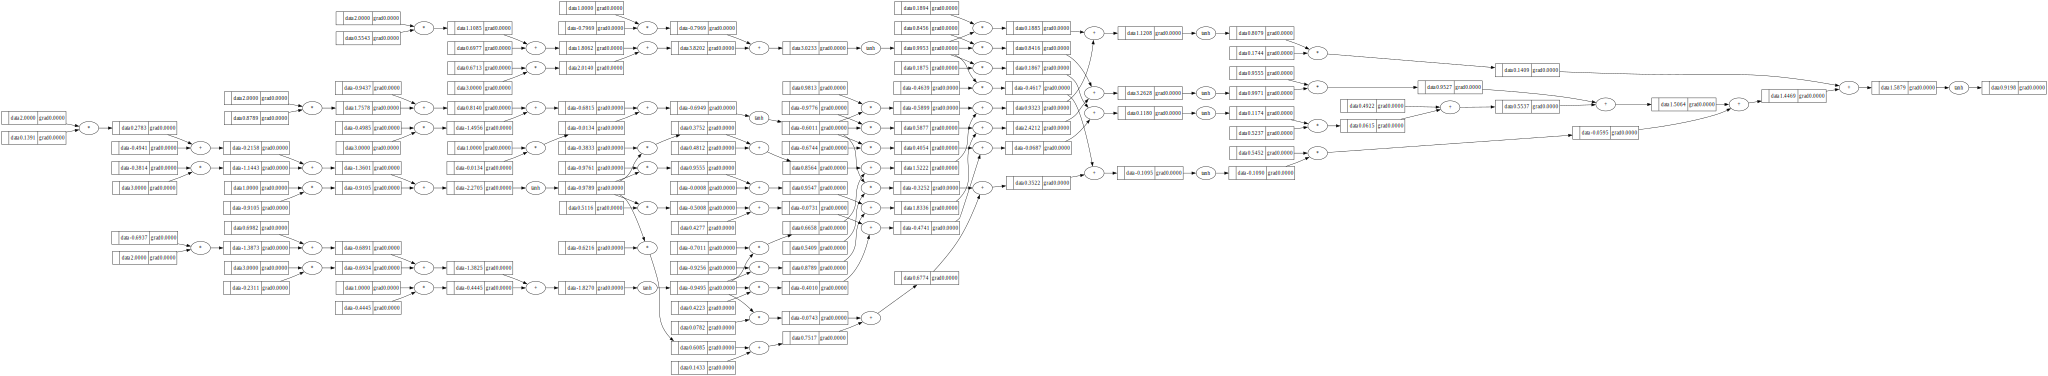

In [31]:
draw_dot(mlp(x))

In [45]:
xs=[[1.2,2.3,4.8],
[2.0,3.0,1.5],
[5.0,4.3,6.6],
[2.1,4.5,8.0]
]
ys=[1.0,-1.0,1.0,-1.0]
y_pred=[mlp(x) for x in xs]
y_pred

[Value(data=-0.3361482978820223),
 Value(data=-0.34125848853023294),
 Value(data=-0.3379666505413354),
 Value(data=-0.337962451231596)]

In [33]:
# loss
# gt : ground truth 
loss=[ (ygt-yout)**2 for ygt,yout in zip(ys,y_pred)]
loss=sum(loss)
loss

Value(data=7.469384594706728)

In [34]:
loss.backward()

In [35]:
mlp.layers[0].neurons[0].w[0].data

0.13914883250534582

In [36]:
mlp.layers[0].neurons[0].w[0].grad

-0.0019833989418050636

In [37]:
for p in mlp.parameters():
    p.data += -0.01*p.grad

In [38]:
mlp.layers[0].neurons[0].w[0].data
# 略微变大了一点,这是对的;梯度的方向是loss增加的方向,我们希望loss减小,因此参数需要反方向做更改

0.13916866649476387

In [39]:
# 重新计算梯度,看是否如我们想的那样loss减少了
y_pred=[mlp(x) for x in xs]
loss=[ (ygt-yout)**2 for ygt,yout in zip(ys,y_pred)]
loss=sum(loss)
loss

Value(data=7.426441683397486)

loss从之前的4.23到现在的2.97,真的降了!

In [40]:
loss.backward() 


In [41]:
# again
for p in mlp.parameters():
    p.data += -0.01*p.grad
y_pred=[mlp(x) for x in xs]
loss=[ (ygt-yout)**2 for ygt,yout in zip(ys,y_pred)]
loss=sum(loss)
loss

Value(data=7.327243355743338)

In [42]:
y_pred

[Value(data=0.926302752354198),
 Value(data=0.8959845983649264),
 Value(data=0.8925702336999287),
 Value(data=0.927566683543911)]

In [43]:
ys

[1.0, -1.0, 1.0, -1.0]

In [176]:
for k in range(20):
    y_pred=[mlp(x) for x in xs]
    loss=sum((ygt-yout)**2  for ygt,yout in zip(ys,y_pred))

    for p in mlp.parameters():
        p.grad=0
    loss.backward()

    for p in mlp.parameters():
        p.data+= -0.1*p.grad
    print(k,loss)

0 Value(data=2.6667498345752803)
1 Value(data=2.666749711971015)
2 Value(data=2.6667495898391476)
3 Value(data=2.6667494681769743)
4 Value(data=2.666749346981545)
5 Value(data=2.6667492262501886)
6 Value(data=2.6667491059800223)
7 Value(data=2.666748986168406)
8 Value(data=2.6667488668125294)
9 Value(data=2.6667487479097813)
10 Value(data=2.666748629457416)
11 Value(data=2.666748511452859)
12 Value(data=2.6667483938934167)
13 Value(data=2.666748276776552)
14 Value(data=2.66674816009963)
15 Value(data=2.666748043860146)
16 Value(data=2.6667479280555146)
17 Value(data=2.666747812683272)
18 Value(data=2.666747697740883)
19 Value(data=2.6667475832259138)


In [177]:
y_pred

[Value(data=0.33334470971289365),
 Value(data=-0.9971253654808543),
 Value(data=0.3333331388818838),
 Value(data=0.3333661687328905)]